In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

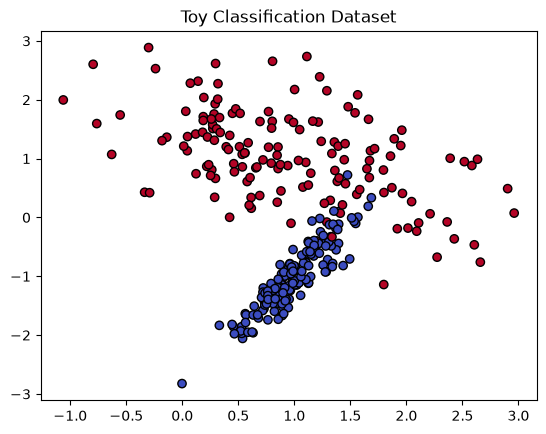

In [2]:
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, 
                             n_informative=2, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Toy Classification Dataset')
plt.show()

In [3]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        distances = np.sqrt(np.sum((X_train - test_point) ** 2, axis=1))
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]
        # Majority vote
        values, counts = np.unique(nearest_labels, return_counts=True)
        predictions.append(values[np.argmax(counts)])
    return np.array(predictions)


my_predictions = knn_predict(X_train, y_train, X_test, k=5)
my_accuracy = accuracy_score(y_test, my_predictions)
print(f"My kNN accuracy: {my_accuracy:.4f}")

My kNN accuracy: 0.9556


In [4]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

print(f"sklearn kNN accuracy: {sklearn_accuracy:.4f}")
print(f"My kNN accuracy: {my_accuracy:.4f}")
print(f"Match: {np.array_equal(my_predictions, sklearn_predictions)}")

sklearn kNN accuracy: 0.9556
My kNN accuracy: 0.9556
Match: True


In [5]:
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(title)

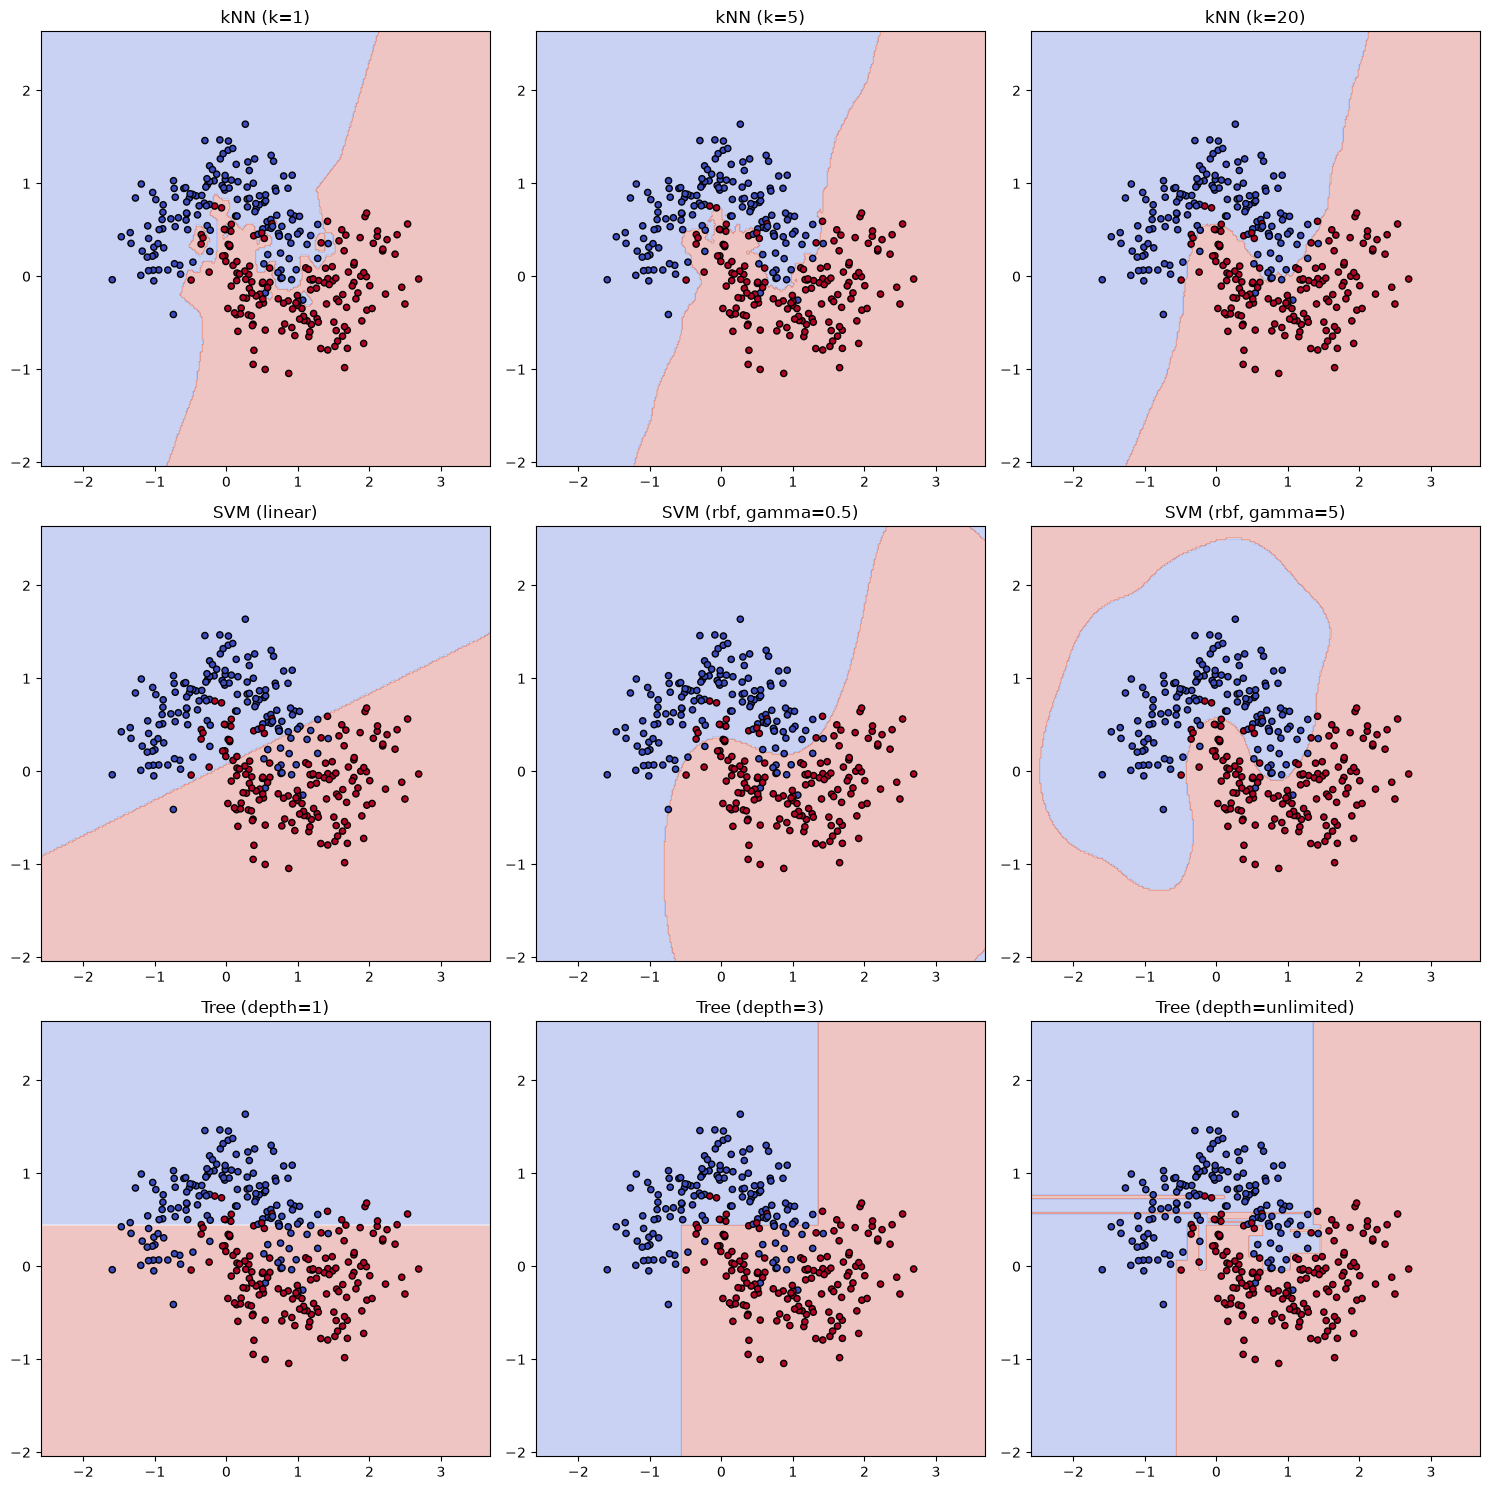

In [6]:
# Use a slightly harder dataset (moons) to show non-linear boundaries better
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Row 1: kNN with different k
for i, k in enumerate([1, 5, 20]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_moon, y_moon)
    plot_decision_boundary(axes[0, i], model, X_moon, y_moon, f'kNN (k={k})')

# Row 2: SVM linear vs RBF (different gamma)
svm_configs = [('linear', 1), ('rbf', 0.5), ('rbf', 5)]
for i, (kernel, gamma) in enumerate(svm_configs):
    model = SVC(kernel=kernel, gamma=gamma if kernel == 'rbf' else 'scale', C=1.0)
    model.fit(X_moon, y_moon)
    label = f'SVM ({kernel}, gamma={gamma})' if kernel == 'rbf' else f'SVM ({kernel})'
    plot_decision_boundary(axes[1, i], model, X_moon, y_moon, label)

# Row 3: Decision tree with different depths
for i, depth in enumerate([1, 3, None]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_moon, y_moon)
    label = f'Tree (depth={depth if depth else "unlimited"})'
    plot_decision_boundary(axes[2, i], model, X_moon, y_moon, label)

plt.tight_layout()
plt.show()

## Decision Boundary Observations

- **kNN**: With k=1, the boundary is very jagged (overfitting to 
  individual points). As k increases, the boundary smooths out, 
  but too large a k (k=20) can oversimplify and blur real structure.

- **SVM**: The linear kernel produces a straight-line boundary, 
  which struggles with the non-linear "moons" shape. The RBF 
  kernel curves to match the data — higher gamma makes the boundary 
  tighter around individual points (risk of overfitting), lower 
  gamma gives smoother, more generalised boundaries.

- **Decision Tree**: A depth-1 tree can only make one split (very 
  simple boundary). As depth increases, boundaries become 
  increasingly rectangular and complex, eventually creating tiny 
  isolated regions around individual noisy points at unlimited 
  depth — a clear overfitting signature.

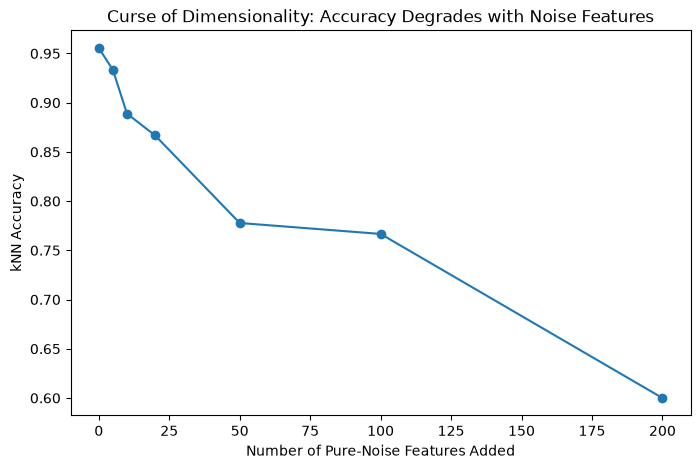

In [7]:
def test_with_noise_features(n_noise_features_list, X_base, y_base):
    accuracies = []
    for n_noise in n_noise_features_list:
        noise_features = np.random.randn(X_base.shape[0], n_noise)
        X_with_noise = np.hstack([X_base, noise_features])
        
        X_tr, X_te, y_tr, y_te = train_test_split(X_with_noise, y_base, test_size=0.3, random_state=42)
        
        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, model.predict(X_te))
        accuracies.append(acc)
    return accuracies


noise_counts = [0, 5, 10, 20, 50, 100, 200]
accuracies = test_with_noise_features(noise_counts, X, y)

plt.figure(figsize=(8, 5))
plt.plot(noise_counts, accuracies, marker='o')
plt.xlabel('Number of Pure-Noise Features Added')
plt.ylabel('kNN Accuracy')
plt.title('Curse of Dimensionality: Accuracy Degrades with Noise Features')
plt.show()

## Curse of Dimensionality

As we add pure-noise features (features with no real signal), kNN 
accuracy degrades. This happens because distance-based methods 
rely on meaningful notions of "closeness" — but in high dimensions, 
distances between points become increasingly uniform (everything 
looks equally far from everything else), diluting the signal from 
the truly informative features. This is the curse of 
dimensionality: more dimensions doesn't mean more information if 
most of those dimensions are noise.

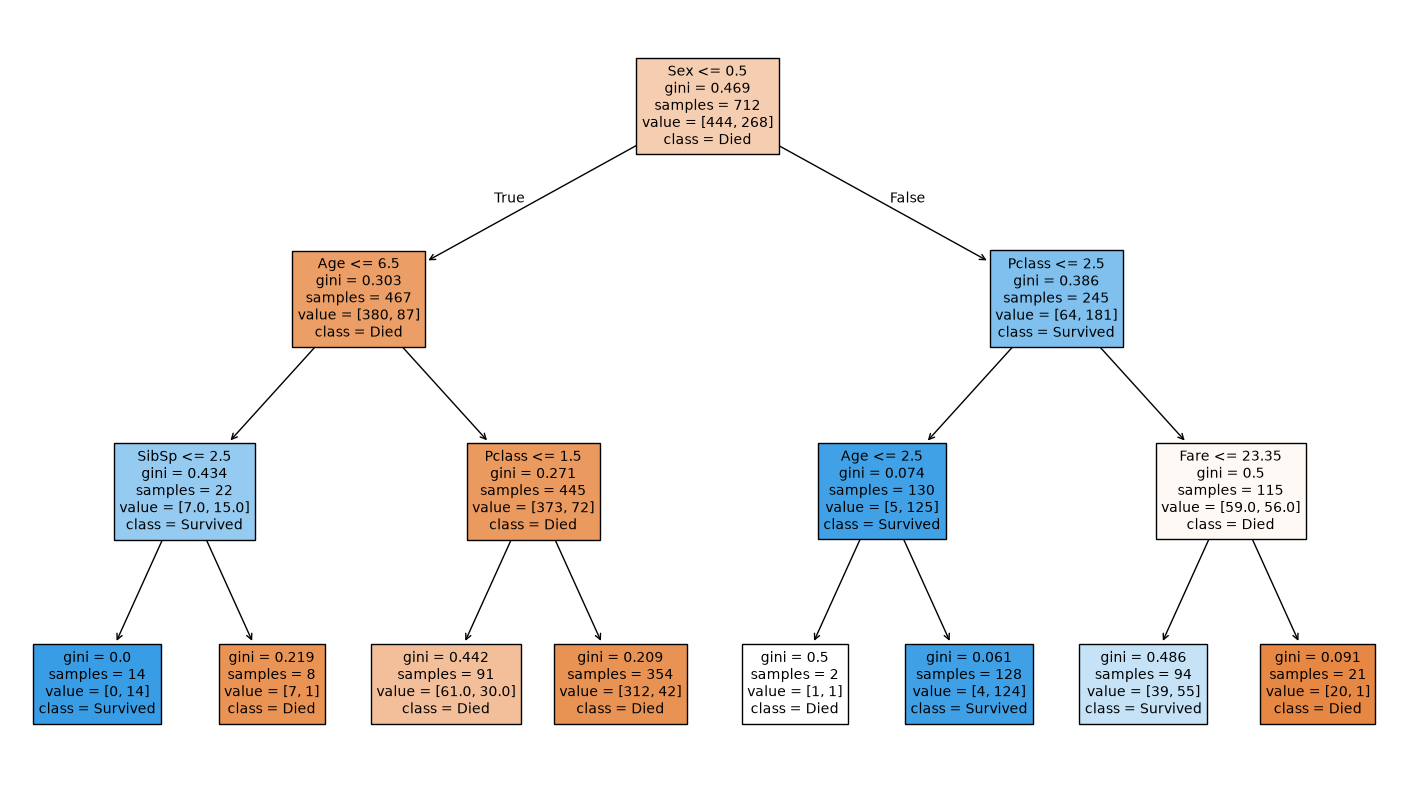

In [8]:
titanic = pd.read_csv('../data/processed/titanic_cleaned.csv')

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X_tree = titanic[features].copy()
X_tree['Sex'] = (titanic['Sex'] == 'female').astype(int)
y_tree = titanic['Survived'].astype(int)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_t, y_train_t)

plt.figure(figsize=(18, 10))
plot_tree(tree_model, feature_names=X_tree.columns, class_names=['Died', 'Survived'], 
          filled=True, fontsize=10)
plt.show()

## Top Three Splits as Business Rules

*(Read these directly from your tree diagram — example structure 
below, adjust based on actual splits)*

1. **Root split (Sex)**: "If the passenger is male, survival 
   chances drop sharply. If female, survival chances are much 
   higher." This confirms Sex is the single most important 
   predictor — women were prioritised in the evacuation.

2. **Second split (Pclass, within one branch)**: "Among male 
   passengers, those in 1st or 2nd class had noticeably better 
   survival odds than 3rd class." This reflects that wealthier 
   passengers had better access to lifeboats.

3. **Third split (Age, within another branch)**: "Among female 
   passengers, very young children had near-certain survival, 
   while older women had somewhat lower (but still high) survival 
   odds." This aligns with "women and children first" evacuation 
   protocol.

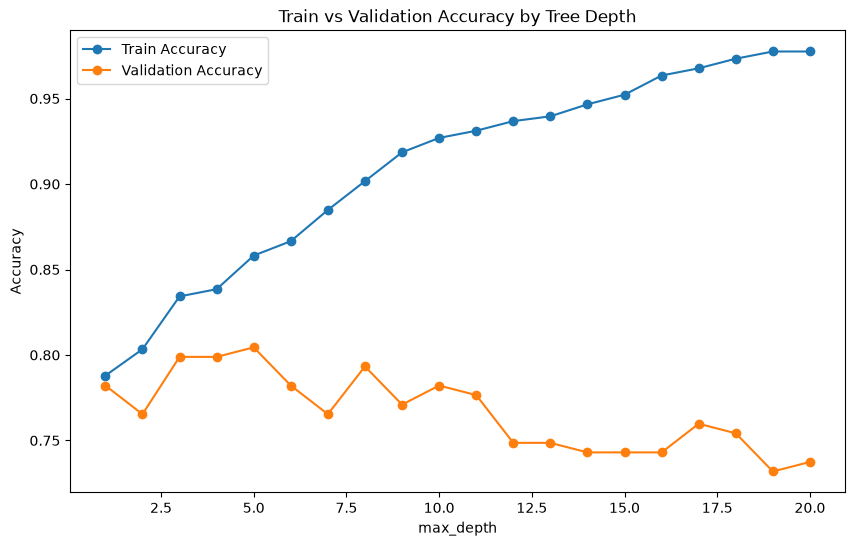

In [9]:
depths = range(1, 21)
train_accs = []
val_accs = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_t, y_train_t)
    train_accs.append(accuracy_score(y_train_t, model.predict(X_train_t)))
    val_accs.append(accuracy_score(y_test_t, model.predict(X_test_t)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy')
plt.plot(depths, val_accs, marker='o', label='Validation Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy by Tree Depth')
plt.legend()
plt.show()

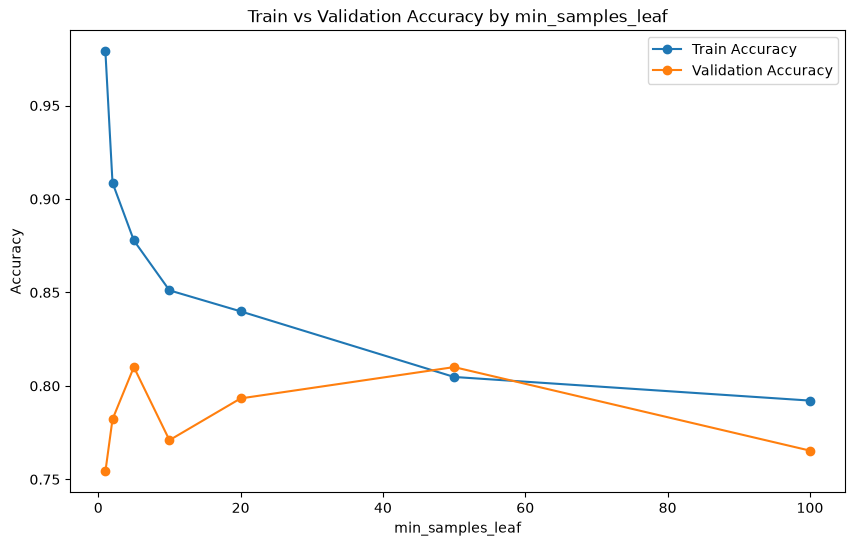

In [10]:
leaf_sizes = [1, 2, 5, 10, 20, 50, 100]
train_accs_leaf = []
val_accs_leaf = []

for leaf_size in leaf_sizes:
    model = DecisionTreeClassifier(min_samples_leaf=leaf_size, random_state=42)
    model.fit(X_train_t, y_train_t)
    train_accs_leaf.append(accuracy_score(y_train_t, model.predict(X_train_t)))
    val_accs_leaf.append(accuracy_score(y_test_t, model.predict(X_test_t)))

plt.figure(figsize=(10, 6))
plt.plot(leaf_sizes, train_accs_leaf, marker='o', label='Train Accuracy')
plt.plot(leaf_sizes, val_accs_leaf, marker='o', label='Validation Accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy by min_samples_leaf')
plt.legend()
plt.show()

## Depth and Leaf Size Tuning

As max_depth increases, training accuracy keeps climbing toward 
1.0 (the tree memorises training data), but validation accuracy 
peaks around depth [X] and then declines — showing overfitting 
beyond that point.

As min_samples_leaf increases, the tree is forced to generalise 
more (each leaf must contain more samples), which reduces 
overfitting up to a point, but too large a value causes 
underfitting, hurting both train and validation accuracy.

The best depth for this dataset appears to be around [X], and the 
best min_samples_leaf around [X], based on where validation 
accuracy peaks.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.space', 'rec.sport.hockey']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, random_state=42)

vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_text = vectorizer.fit_transform(newsgroups.data)
y_text = newsgroups.target

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42
)

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train_nb)
nb_acc = accuracy_score(y_test_nb, nb_model.predict(X_test_nb))
print(f"Naive Bayes text classification accuracy: {nb_acc:.4f}")